# Import the Required Libraries #

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Import the CSV file Data as Pandas Data Frame #

In [ ]:
df=pd.read_csv('/Volumes/E Drive/Learning Curve/Data Science Projects/ML Project/First ML Project/notebook/data/Studper.csv')
print(df.head())
df.shape

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


(1000, 8)

### 2.2 Dataset Information ###
##### 1. Gender: Sex of students --> (Male / Female)
##### 2. Race / Ethnicity: Ethnixity of Students:--> (Group A,B,C,D,E)
##### 3. Parental Level of Education: Bachelor Degree,College Student, Master Degree,Associate's degree 
##### 4. Lunch: Having lunch before test(Standard or Free / Reduced)
##### 5. Test Prep Course: Complete / Not complete befre test 
##### 6. Math Score
##### 7. Reading Score
##### 8. Writing Score


### 3. Data Checks to Perform and Analysis

#### Check Missing values
#### Checks Duplicates
#### Check data type
#### Check the number of unique values of each column
#### Check statistics of data set 
#### Check various categories present in the differnt categorical column 


In [ ]:
# 3.1 Check the Missing values 
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [ ]:
# Check the Duplicate values and test the number of duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check Null & Data Type Value
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Insights #

#### From above description of Numerical Data , all means are very close to each other between 66 and 68.05

#### All standard deviations are also close between14.6 and 15.19 
#### While there is minimum score 0 for math, for writing minimum is much higher = 10 and for reading mgiht higher=17

# Exploring Data

In [ ]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())
print("categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())
print("categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())
print("categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())
print("categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [ ]:
# Define the categorical and numerical columns
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print('We have {} Numerical features: {}' .format(len(numerical_features),numerical_features)) 
print('We have {} Categorical features: {}' .format(len(categorical_features),categorical_features)) 

We have 8 Numerical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
We have 0 Categorical features: []


## Adding Columns for "Total Score" and "Average"

In [ ]:
df['Total Score']=df['math score']+df['reading score']+df['writing score']
df['Average Score']=df['Total Score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
reading_full= df[df['reading score']==100]['Average Score'].count()
writing_full= df[df['writing score']==100]['Average Score'].count()
math_full= df[df['math score']==100]['Average Score'].count()
print('Number of students who scored 100 in Reading: ',reading_full)
print('Number of students who scored 100 in Writing: ',writing_full)
print('Number of students who scored 100 in Math: ',math_full)

Number of students who scored 100 in Reading:  17
Number of students who scored 100 in Writing:  14
Number of students who scored 100 in Math:  7


In [ ]:
reading_less_20=df[df['reading score']<20]['Average Score'].count()
writing_less_20=df[df['writing score']<20]['Average Score'].count()
math_less_20=df[df['math score']<20]['Average Score'].count()
print('Number of students who scored less than 20 in Reading: ',reading_less_20)
print('Number of students who scored less than 20 in Writing: ',writing_less_20)
print('Number of students who scored less than 20 in Math: ',math_less_20)

Number of students who scored less than 20 in Reading:  1
Number of students who scored less than 20 in Writing:  3
Number of students who scored less than 20 in Math:  4


#### 4.1 Histogram & KDE

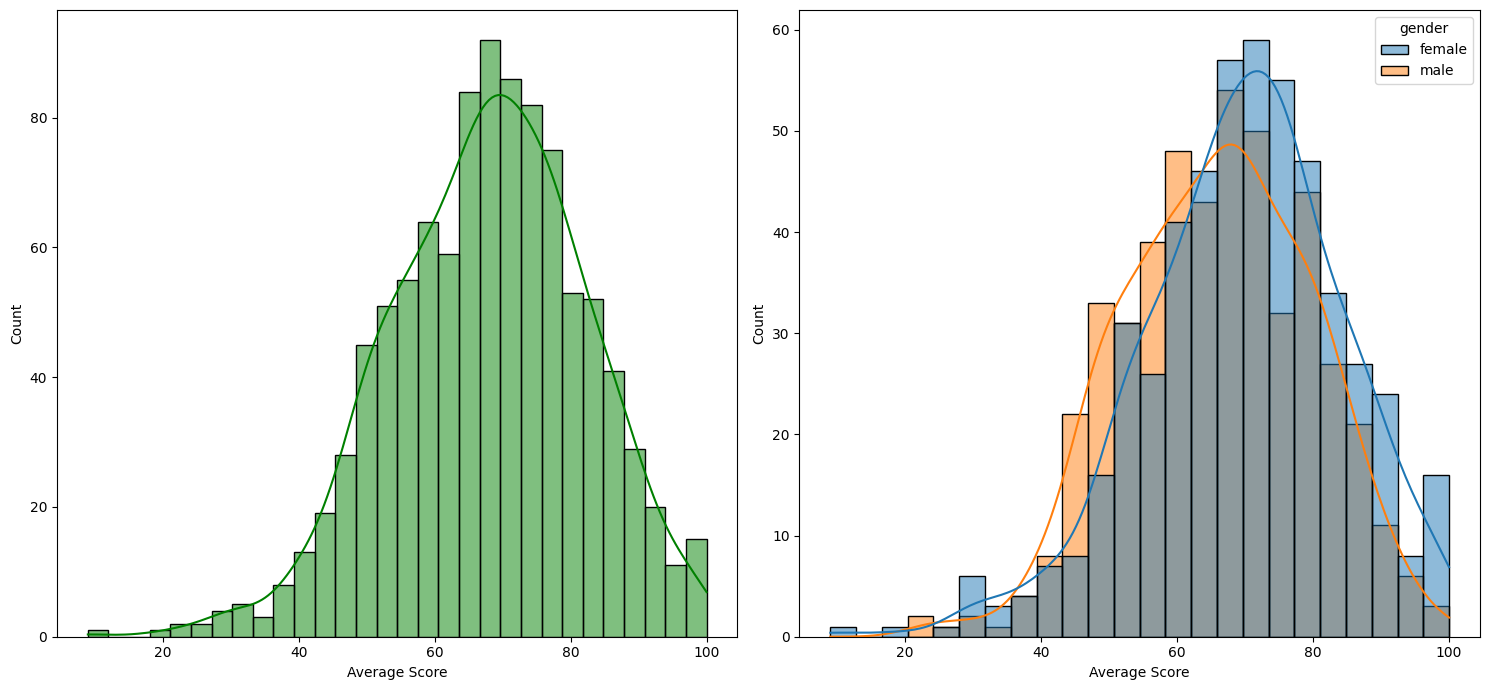

In [ ]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average Score',kde=True,hue='gender')
plt.tight_layout()
plt.show()

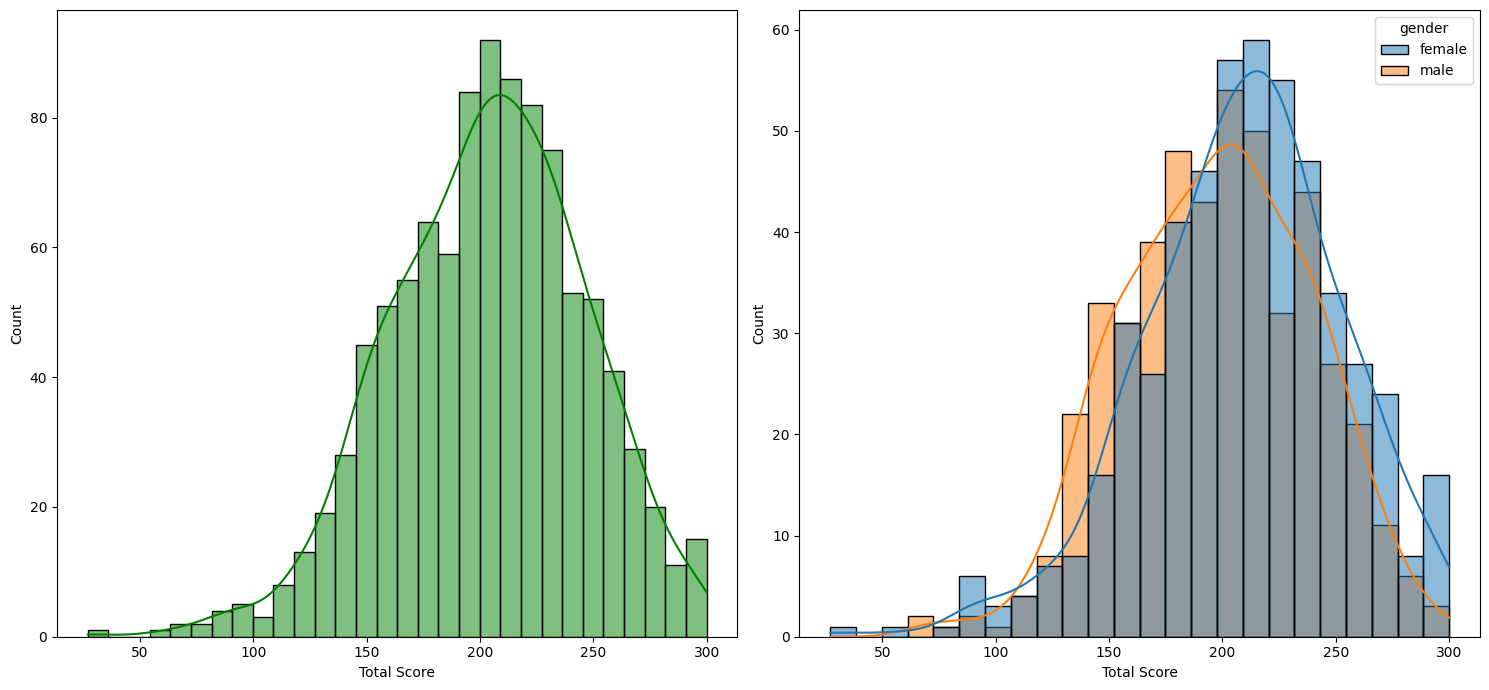

In [ ]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total Score',kde=True,hue='gender')
plt.tight_layout()
plt.show()

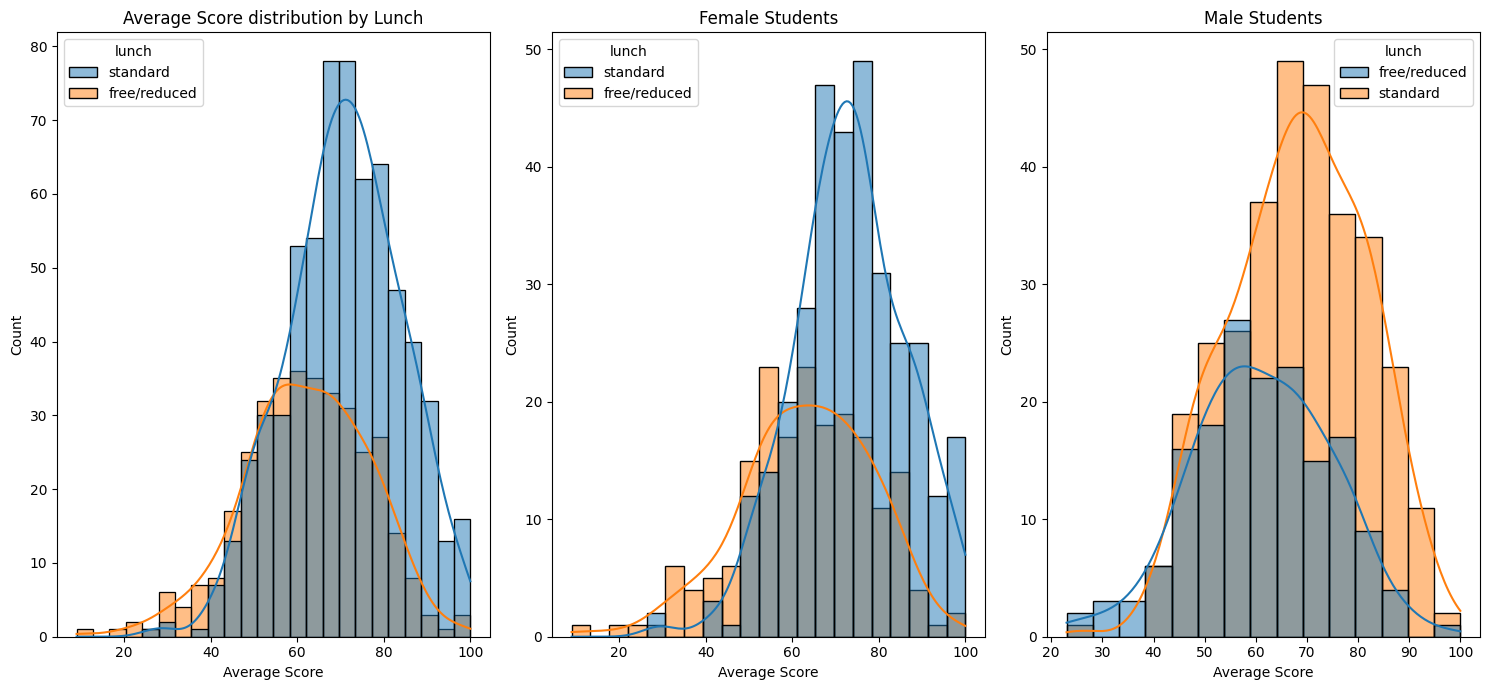

In [ ]:
fig,axes =plt.subplots(1,3, figsize=(15,7))
sns.histplot(data=df,x='Average Score',kde=True,hue='lunch',ax=axes[0])
axes[0].set_title('Average Score distribution by Lunch')
sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='lunch',ax=axes[1])
axes[1].set_title('Female Students')
sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='lunch',ax=axes[2])
axes[2].set_title('Male Students')
plt.tight_layout()
plt.show()

### Additional Improvements:
#### If you want to handle potential missing data:

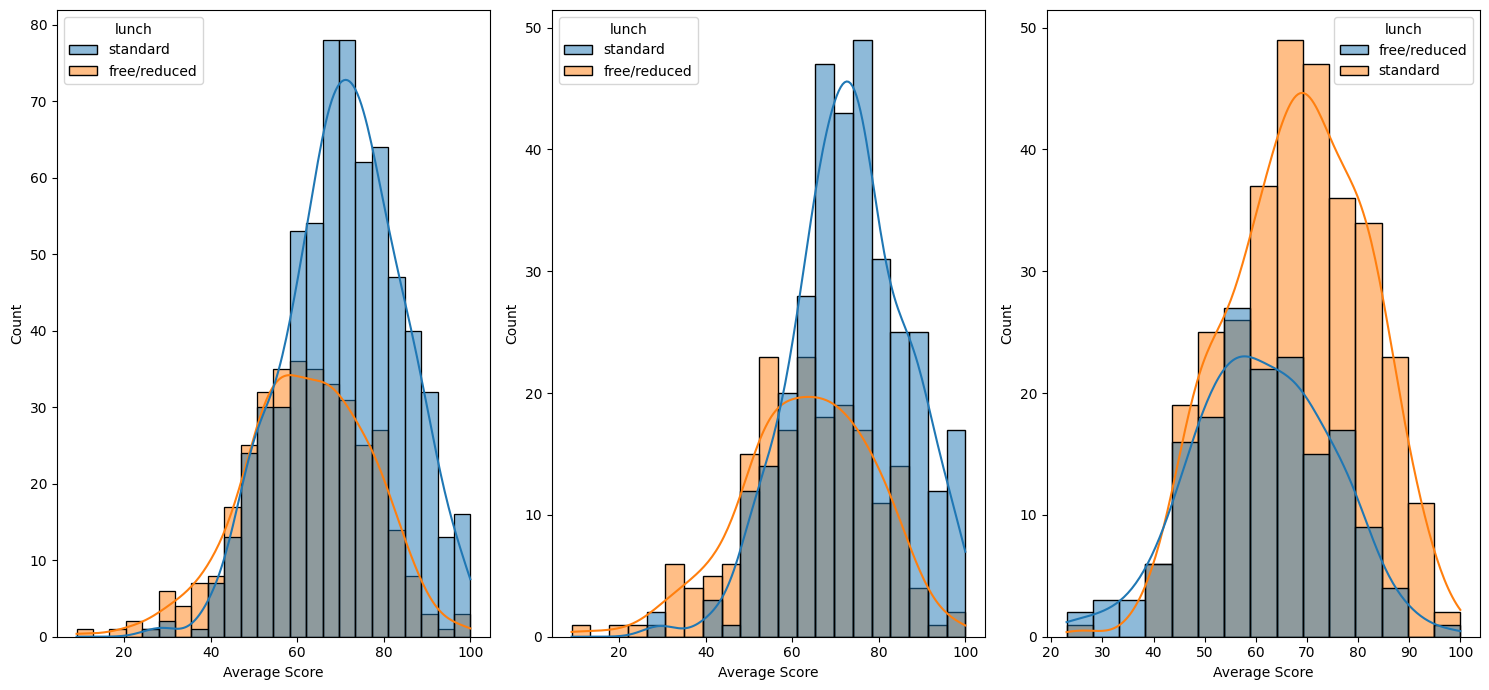

In [ ]:
plt.figure(figsize=(15, 7))

# Remove any null values in gender or Average score
clean_df = df.dropna(subset=['gender', 'Average Score', 'lunch'])

plt.subplot(131)
sns.histplot(data=clean_df, x='Average Score', kde=True, hue='lunch')

plt.subplot(132)
female_data = clean_df[clean_df.gender == 'female']
if not female_data.empty:
    sns.histplot(data=female_data, x='Average Score', kde=True, hue='lunch')
else:
    plt.text(0.5, 0.5, 'No female students data', ha='center', va='center')

plt.subplot(133)
male_data = clean_df[clean_df.gender == 'male']
if not male_data.empty:
    sns.histplot(data=male_data, x='Average Score', kde=True, hue='lunch')
else:
    plt.text(0.5, 0.5, 'No male students data', ha='center', va='center')

plt.tight_layout()
plt.show()

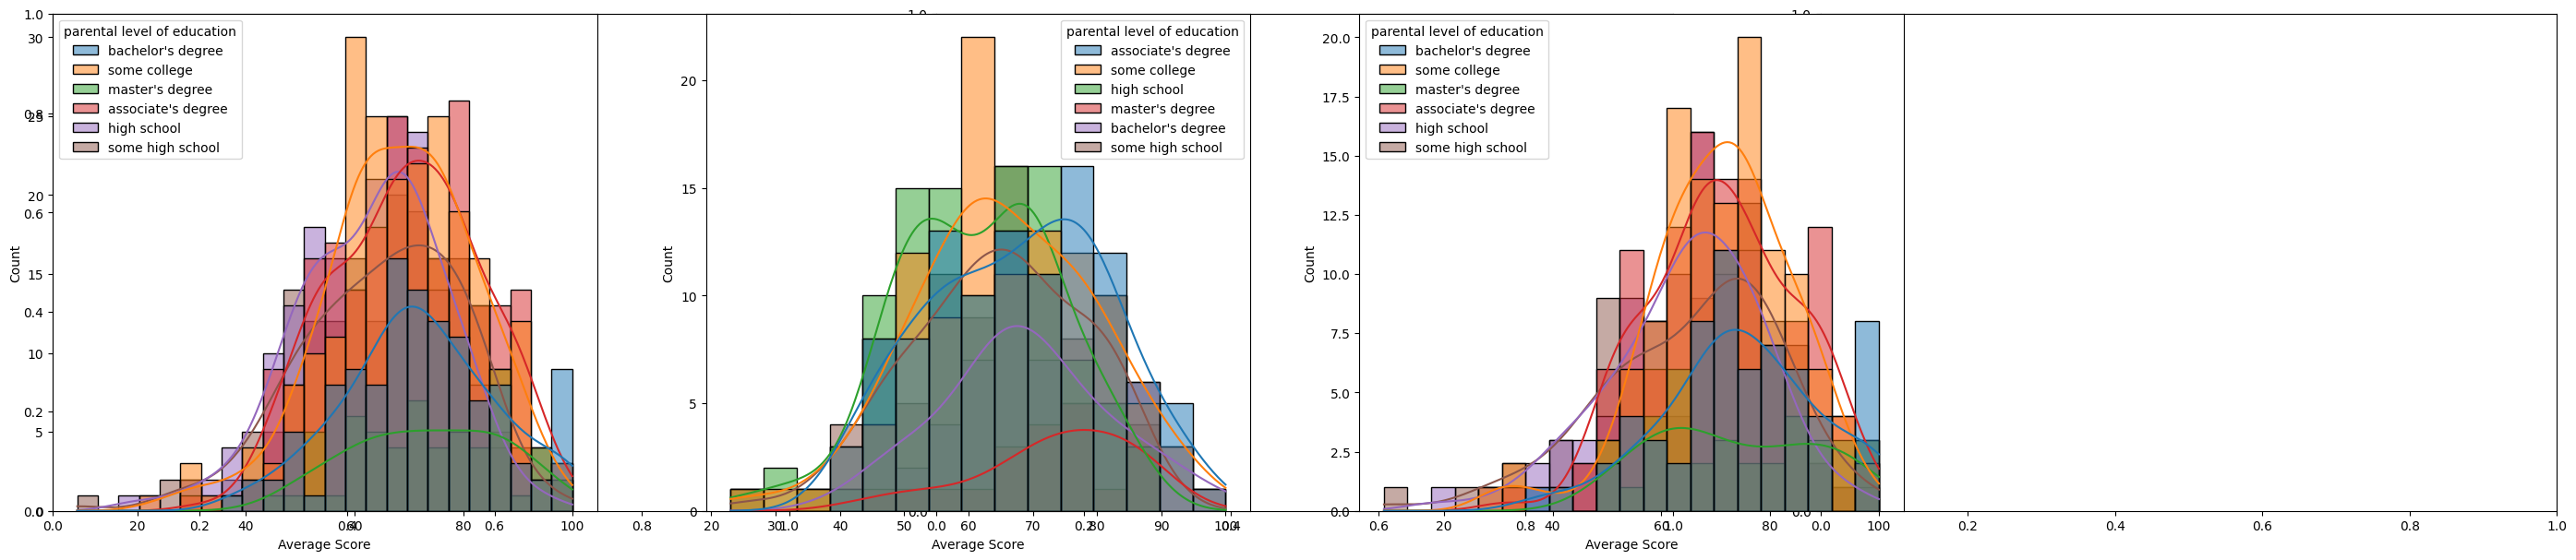

In [ ]:
plt.subplots(1,3,figsize=(35,7))
plt.subplot(141)
ax =sns.histplot(data=df,x='Average Score',kde=True,hue='parental level of education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='parental level of education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='parental level of education')
plt.tight_layout()
plt.show()

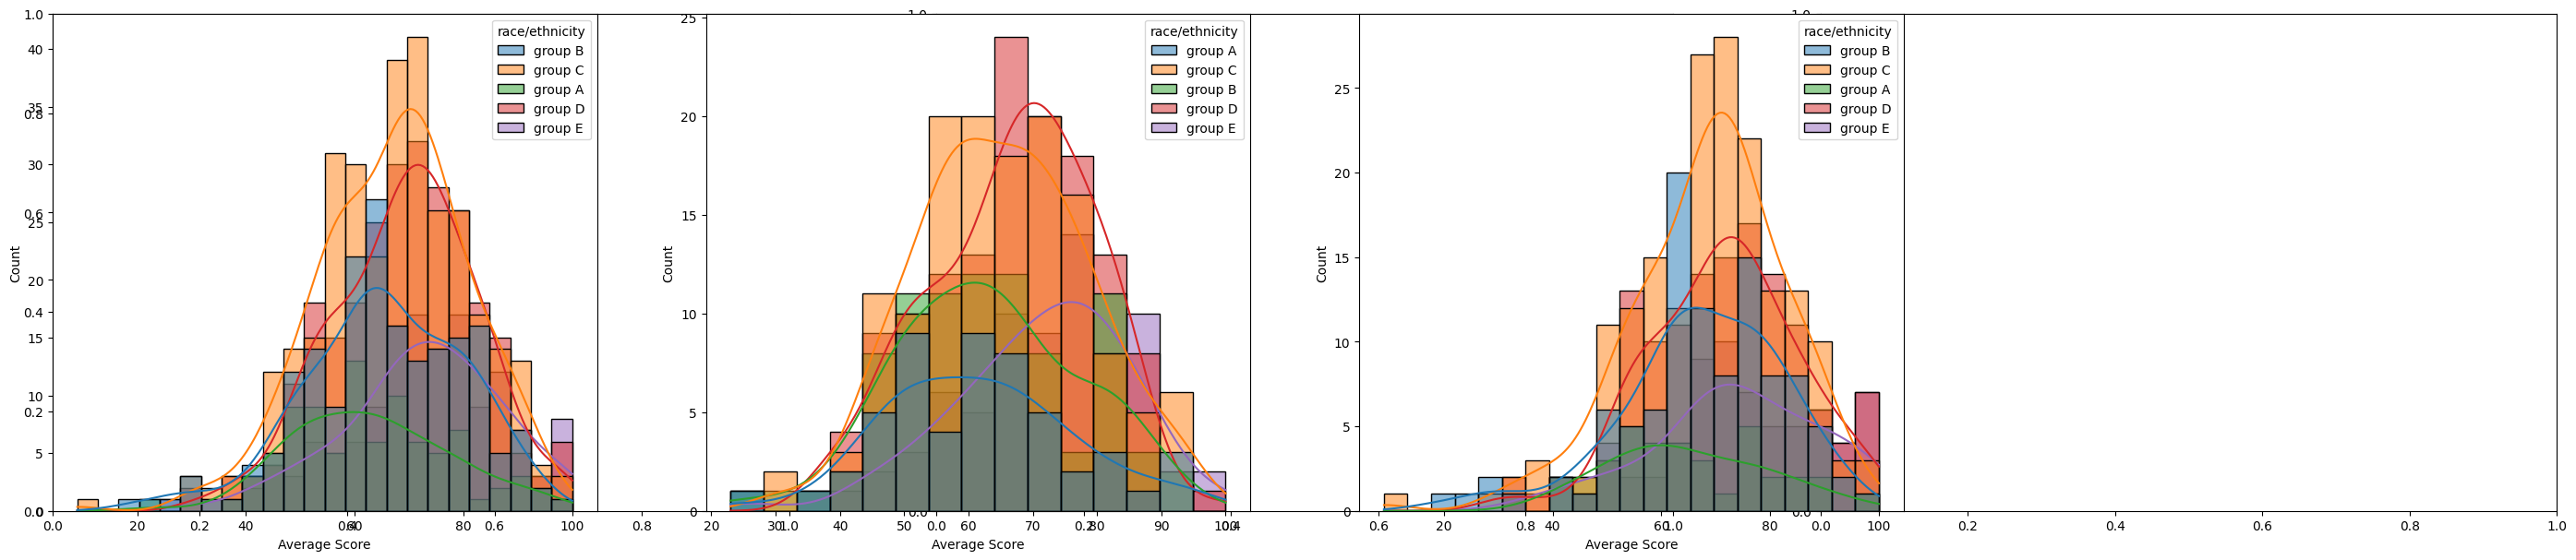

In [ ]:
plt.subplots(1,3,figsize=(35,7))
plt.subplot(141)
ax =sns.histplot(data=df,x='Average Score',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='race/ethnicity')
plt.tight_layout()
plt.show()      

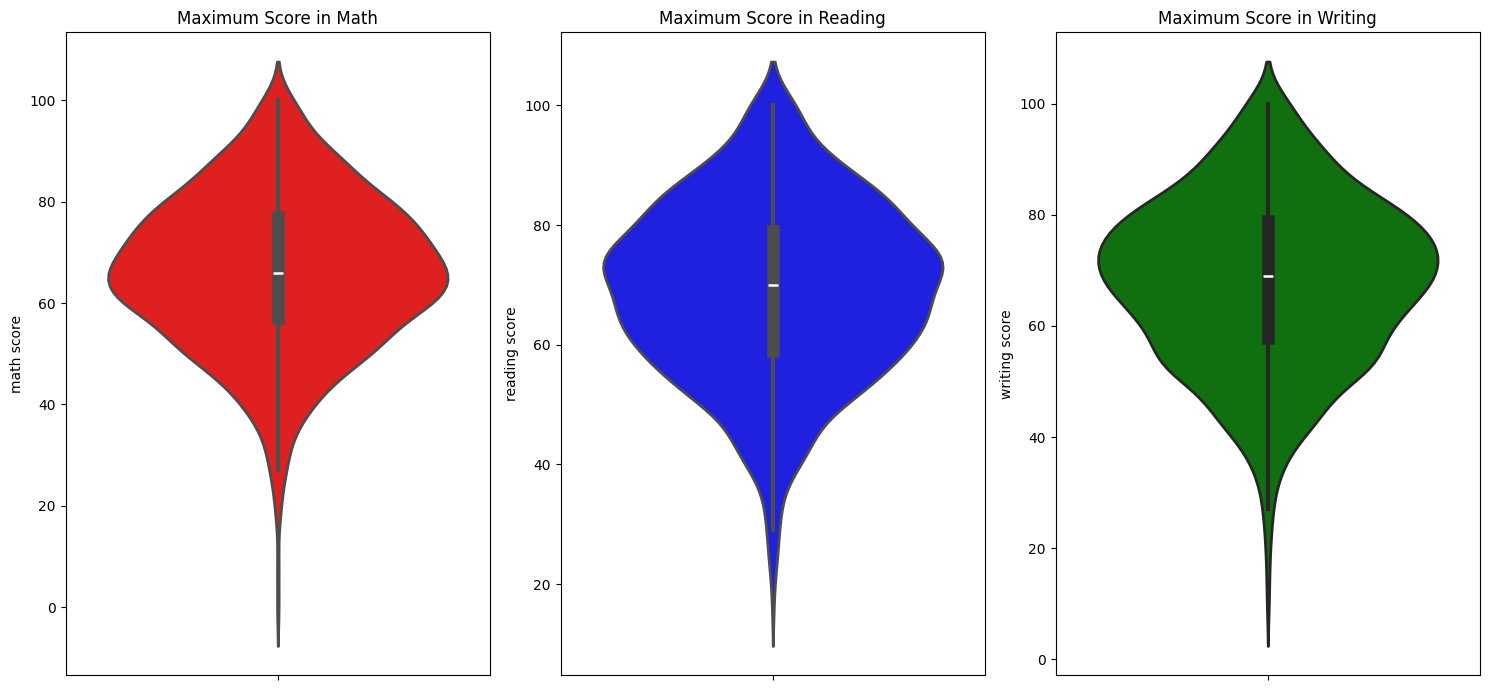

In [ ]:
# 4.2 Maximum score of students in all three subjects
plt.figure(figsize=(15, 7))
plt.subplot(131)
plt.title('Maximum Score in Math')
sns.violinplot(y='math score',data=df,color='red',linewidth=2)
plt.subplot(132)
plt.title('Maximum Score in Reading')
sns.violinplot(y='reading score',data=df,color='blue',linewidth=2)
plt.subplot(133)
plt.title('Maximum Score in Writing')
sns.violinplot(y='writing score',data=df,color='green',linewidth=2)
plt.tight_layout()
plt.show()